<div style="text-align: center; padding: 40px 20px; background: linear-gradient(135deg, #2193b0 0%, #6dd5ed 100%); color: white; border-radius: 10px; margin-bottom: 30px;">

# **Page Funnel Visits Analysis**

<br>

### Instituto Tecnológico y de Estudios Superiores de Occidente

<br>

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR8BoqpyeDOyQhom4iu4RXfd939K9RUSdigOg&s" alt="ITESO Logo" width="220" style="background: white; padding: 10px; border-radius: 10px;"/>

<br><br>

### **Alumno:** Luis Fernando Márquez Bañuelos

### **Profesor:** Rodolfo Slay

### **Materia:** Modelos de Crédito

<br><br>

<img src="https://popsql.com/static/images/templates/funnel_steps.png" alt="Funnel Analysis" width="400" style="border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.3);"/>

</div>

### If a step is a question, answer the question after you solve it! -> print("This is the answer")

In [1]:
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

Import all the files

In [2]:
visits = pd.read_csv('data/visits.csv',
                     parse_dates=[1])

cart = pd.read_csv('data/cart.csv',
                   parse_dates=[1])     

checkout = pd.read_csv('data/checkout.csv',
                       parse_dates=[1])

purchase = pd.read_csv('data/purchase.csv',
                       parse_dates=[1])

Step 1: Inspect the DataFrames using `print` and `head`

In [3]:
display(visits.head())
display(cart.head())
display(checkout.head())
display(purchase.head())

,user_id,visit_time
0,943647ef-3682-4750-a2e1-918ba6f16188,2017-04-07 15:14:00
1,0c3a3dd0-fb64-4eac-bf84-ba069ce409f2,2017-01-26 14:24:00
2,6e0b2d60-4027-4d9a-babd-0e7d40859fb1,2017-08-20 08:23:00
3,6879527e-c5a6-4d14-b2da-50b85212b0ab,2017-11-04 18:15:00
4,a84327ff-5daa-4ba1-b789-d5b4caf81e96,2017-02-27 11:25:00


,user_id,cart_time
0,2be90e7c-9cca-44e0-bcc5-124b945ff168,2017-11-07 20:45:00
1,4397f73f-1da3-4ab3-91af-762792e25973,2017-05-27 01:35:00
2,a9db3d4b-0a0a-4398-a55a-ebb2c7adf663,2017-03-04 10:38:00
3,b594862a-36c5-47d5-b818-6e9512b939b3,2017-09-27 08:22:00
4,a68a16e2-94f0-4ce8-8ce3-784af0bbb974,2017-07-26 15:48:00


,user_id,checkout_time
0,d33bdc47-4afa-45bc-b4e4-dbe948e34c0d,2017-06-25 09:29:00
1,4ac186f0-9954-4fea-8a27-c081e428e34e,2017-04-07 20:11:00
2,3c9c78a7-124a-4b77-8d2e-e1926e011e7d,2017-07-13 11:38:00
3,89fe330a-8966-4756-8f7c-3bdbcd47279a,2017-04-20 16:15:00
4,3ccdaf69-2d30-40de-b083-51372881aedd,2017-01-08 20:52:00


,user_id,purchase_time
0,4b44ace4-2721-47a0-b24b-15fbfa2abf85,2017-05-11 04:25:00
1,02e684ae-a448-408f-a9ff-dcb4a5c99aac,2017-09-05 08:45:00
2,4b4bc391-749e-4b90-ab8f-4f6e3c84d6dc,2017-11-20 20:49:00
3,a5dbb25f-3c36-4103-9030-9f7c6241cd8d,2017-01-22 15:18:00
4,46a3186d-7f5a-4ab9-87af-84d05bfd4867,2017-06-11 11:32:00


Step 2: Left merging visits and cart

In [4]:
visits_cart = visits.merge(cart, how='left')
visits_cart

,user_id,visit_time,cart_time
0,943647ef-3682-4750-a2e1-918ba6f16188,2017-04-07 15:14:00,NaT
1,0c3a3dd0-fb64-4eac-bf84-ba069ce409f2,2017-01-26 14:24:00,2017-01-26 14:44:00
2,6e0b2d60-4027-4d9a-babd-0e7d40859fb1,2017-08-20 08:23:00,2017-08-20 08:31:00
3,6879527e-c5a6-4d14-b2da-50b85212b0ab,2017-11-04 18:15:00,NaT
4,a84327ff-5daa-4ba1-b789-d5b4caf81e96,2017-02-27 11:25:00,NaT
...,...,...,...
1995,33913ac2-03da-45ae-8fc3-fea39df827c6,2017-03-25 03:29:00,NaT
1996,4f850132-b99d-4623-80e6-6e61d003577e,2017-01-08 09:57:00,NaT
1997,f0830b9b-1f5c-4e74-b63d-3f847cc6ce70,2017-09-07 12:56:00,NaT
1998,b01bffa7-63ba-4cd3-9d93-eb1477c23831,2017-07-20 04:37:00,NaT


Step 3: How long is `visits_cart`?

In [5]:
print("This is the answer:")
print(f'visits_car has a length of: {len(visits_cart)}')

This is the answer:
visits_car has a length of: 2000


Step 4: How many timestamps are null for `cart_time`?

In [6]:
null_cart_time = visits_cart.cart_time.isnull().sum()

print("This is the answer:")
print(f'The number of null cart_time values is: {null_cart_time}')

This is the answer:
The number of null cart_time values is: 1652


Step 5: What percentage only visited?

In [7]:
visited_not_cart = null_cart_time / len(visits_cart)

print("This is the answer:")
print(f'The percentage of visits that did not add to cart is: {visited_not_cart:.2%}')

This is the answer:
The percentage of visits that did not add to cart is: 82.60%


Step 6: What percentage placed a t-shirt in their cart but did not checkout?

In [8]:
cart_checkout = cart.merge(checkout, how='left')

not_checkout = cart_checkout.checkout_time.isnull().mean()

print("This is the answer:")
print(f"{not_checkout:.2%} of shoppers placed a t-shirt in their cart but did not checkout.")

This is the answer:
35.06% of shoppers placed a t-shirt in their cart but did not checkout.


Step 7: Merge it all together

In [9]:
all_data = visits_cart.merge(checkout, how='left').merge(purchase, how='left')
all_data

,user_id,visit_time,cart_time,checkout_time,purchase_time
0,943647ef-3682-4750-a2e1-918ba6f16188,2017-04-07 15:14:00,NaT,NaT,NaT
1,0c3a3dd0-fb64-4eac-bf84-ba069ce409f2,2017-01-26 14:24:00,2017-01-26 14:44:00,2017-01-26 14:54:00,2017-01-26 15:08:00
2,6e0b2d60-4027-4d9a-babd-0e7d40859fb1,2017-08-20 08:23:00,2017-08-20 08:31:00,NaT,NaT
3,6879527e-c5a6-4d14-b2da-50b85212b0ab,2017-11-04 18:15:00,NaT,NaT,NaT
4,a84327ff-5daa-4ba1-b789-d5b4caf81e96,2017-02-27 11:25:00,NaT,NaT,NaT
...,...,...,...,...,...
2103,33913ac2-03da-45ae-8fc3-fea39df827c6,2017-03-25 03:29:00,NaT,NaT,NaT
2104,4f850132-b99d-4623-80e6-6e61d003577e,2017-01-08 09:57:00,NaT,NaT,NaT
2105,f0830b9b-1f5c-4e74-b63d-3f847cc6ce70,2017-09-07 12:56:00,NaT,NaT,NaT
2106,b01bffa7-63ba-4cd3-9d93-eb1477c23831,2017-07-20 04:37:00,NaT,NaT,NaT


Step 8: % of users who got to checkout but did not purchase

In [10]:
purchased_checkout = all_data.purchase_time.notnull().sum() / all_data.checkout_time.notnull().sum()

print("This is the answer:")
print(f'The percentage of shoppers that checked out and not purchased is: {1 - purchased_checkout:.2%}')

This is the answer:
The percentage of shoppers that checked out and not purchased is: 24.55%


Step 9: check each part of the funnel, let's print all 3 of them again

In [11]:
print("This is the answer:")
print("{} percent of users who visited the page did not add a t-shirt to their cart".format(round(visited_not_cart*100, 2)))
print("{} percent of users who added a t-shirt to their cart did not checkout".format(round(not_checkout*100, 2)))
print("{} percent of users who made it to checkout did not purchase a shirt".format(round( (1-purchased_checkout)*100, 2)))

This is the answer:
82.6 percent of users who visited the page did not add a t-shirt to their cart
35.06 percent of users who added a t-shirt to their cart did not checkout
24.55 percent of users who made it to checkout did not purchase a shirt


*The weakest part of the funnel is clearly getting a person who visited the site to add a tshirt to their cart. Once they've added a t-shirt to their cart it is fairly likely they end up purchasing it. A suggestion could be to make the add-to-cart button more prominent on the front page.*


Step 10: adding new column

In [12]:
all_data['time_to_purchase'] = all_data.purchase_time - all_data.visit_time
all_data

,user_id,visit_time,cart_time,checkout_time,purchase_time,time_to_purchase
0,943647ef-3682-4750-a2e1-918ba6f16188,2017-04-07 15:14:00,NaT,NaT,NaT,NaT
1,0c3a3dd0-fb64-4eac-bf84-ba069ce409f2,2017-01-26 14:24:00,2017-01-26 14:44:00,2017-01-26 14:54:00,2017-01-26 15:08:00,0 days 00:44:00
2,6e0b2d60-4027-4d9a-babd-0e7d40859fb1,2017-08-20 08:23:00,2017-08-20 08:31:00,NaT,NaT,NaT
3,6879527e-c5a6-4d14-b2da-50b85212b0ab,2017-11-04 18:15:00,NaT,NaT,NaT,NaT
4,a84327ff-5daa-4ba1-b789-d5b4caf81e96,2017-02-27 11:25:00,NaT,NaT,NaT,NaT
...,...,...,...,...,...,...
2103,33913ac2-03da-45ae-8fc3-fea39df827c6,2017-03-25 03:29:00,NaT,NaT,NaT,NaT
2104,4f850132-b99d-4623-80e6-6e61d003577e,2017-01-08 09:57:00,NaT,NaT,NaT,NaT
2105,f0830b9b-1f5c-4e74-b63d-3f847cc6ce70,2017-09-07 12:56:00,NaT,NaT,NaT,NaT
2106,b01bffa7-63ba-4cd3-9d93-eb1477c23831,2017-07-20 04:37:00,NaT,NaT,NaT,NaT


Step 11: examine the results

In [13]:
all_data.time_to_purchase.describe()

count                          252
mean     0 days 00:43:12.380952380
std      0 days 00:14:42.168126436
min                0 days 00:09:00
25%                0 days 00:32:00
50%                0 days 00:44:30
75%                0 days 00:54:00
max                0 days 01:17:00
Name: time_to_purchase, dtype: object

Step 12: what is the average time to purchase?

In [14]:
avg_time = all_data.time_to_purchase.mean()

print("This is the answer:")
print(f"The average time from visit to purchase is: {avg_time}")

This is the answer:
The average time from visit to purchase is: 0 days 00:43:12.380952380


## <font color = 'cornflowerblue'> Sankey Diagram

In [15]:
# Calculate the flow values for the Sankey diagram
total_visits = len(all_data)
visited_to_cart = all_data.cart_time.notnull().sum()
visited_no_cart = total_visits - visited_to_cart
cart_to_checkout = all_data.checkout_time.notnull().sum()
cart_no_checkout = visited_to_cart - cart_to_checkout
checkout_to_purchase = all_data.purchase_time.notnull().sum()
checkout_no_purchase = cart_to_checkout - checkout_to_purchase

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=["Visited Page", "Added to Cart", "Reached Checkout", "Purchased", "Dropped at Visit", "Dropped at Cart", "Dropped at Checkout"],
        color=["blue", "green", "orange", "purple", "red", "red", "red"]
    ),
    link=dict(
        source=[0, 0, 1, 1, 2, 2],  # indices correspond to labels
        target=[1, 4, 2, 5, 3, 6],
        value=[visited_to_cart, visited_no_cart, cart_to_checkout, cart_no_checkout, checkout_to_purchase, checkout_no_purchase]
    )
)])

fig.update_layout(title_text="E-commerce Funnel - Sankey Diagram", font_size=12)
fig.show()

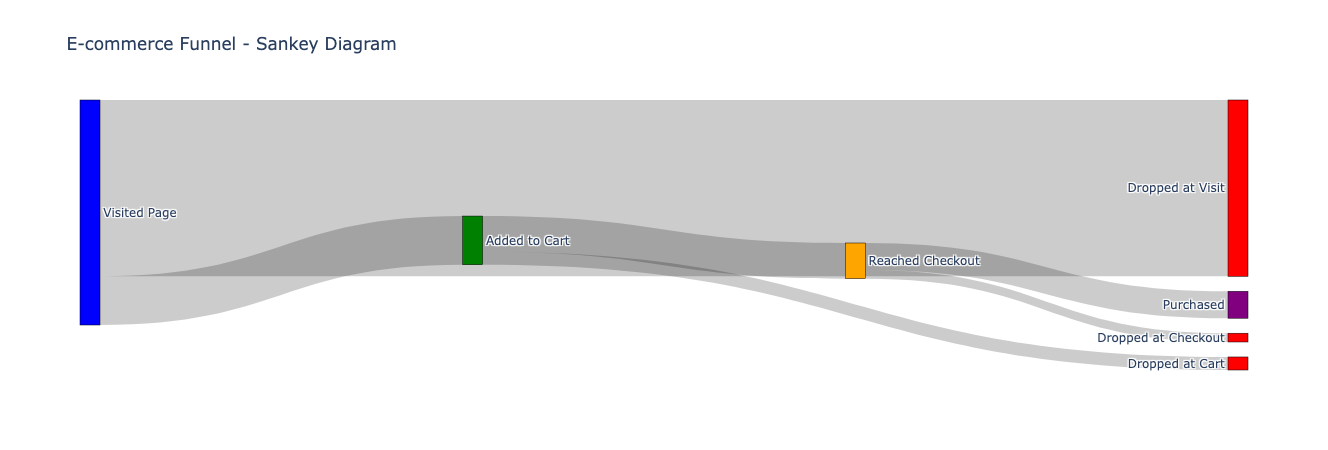